# SA-HTDemucs - Evaluation & Baseline Comparison (test only)

This notebook **evaluates and compares** one or more trained `SpatialCueModule`
head sets of `SA-HTDemucs` against the frozen pre-trained HT-Demucs baseline.
Only the lightweight spatial heads differ between runs, while the backbone is the
same frozen HT-Demucs in every case. Each run is produced headless by

```bash
python -m sahtdemucs.train \
    --dataset-root <binauralMUSDB18HQ> \
    --out-root     <runs-root> \
    --epochs 250
```

Training lives entirely in that script. This notebook discovers the run
directories under `RUNS_ROOT`, plots their training curves, rebuilds each head
set from its `config.json`, separates the test mixtures and reports the two
metrics that matter for the trade-off between separation quality and spatial
fidelity:

- **SI-SDR** (dB) - separation quality; should stay close to the baseline.
- **Per-sub-band ILD MAE** (dB) - residual interaural level-difference error;
  lower means the binaural level cue is better preserved.

Both metrics reuse the exact sub-band cue definitions of the training loss
(`sahtdemucs.metrics`), and the band layout is read from each run's `config.json`
so the comparison is consistent with how the heads were trained.

> **Prerequisite:** `pip install demucs`

In [1]:
import sys
from pathlib import Path

# Robustly locate the project root (the folder containing the `sahtdemucs` package)
_cwd = Path().resolve()
_project_root = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / 'sahtdemucs' / '__init__.py').exists()),
    _cwd.parent,
)
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import io
import json
import time
import zipfile
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchaudio

from demucs.pretrained import get_model
from demucs.apply import apply_model
from sahtdemucs.model import SAHTDemucs
from sahtdemucs.dataset import load_audio
from sahtdemucs.spatial import mel_bin_assignment
from sahtdemucs.metrics import si_sdr, ild_bands_mae, itd_bands_mae

## Configuration

In [2]:
# -- Remote or local ----------------------------------------------------------
remote = True

# -- Paths --------------------------------------------------------------------
# RUNS_ROOT is the --out-root passed to `python -m sahtdemucs.train`: it holds one
# sub-directory per run, each with a `spatial_modules_<run>.pt` best checkpoint,
# a `config.json` and a `history_<run>.json`.  DATASET_ROOT/test provides the
# mixtures + ground-truth stems.
if remote:
    DATASET_ROOT = Path("/nas/home/macerbi/dataset/binauralmusdb18hq")
    RUNS_ROOT    = Path("/nas/home/macerbi/sahtdemucs/runs/sahtdemucs")
else:
    DATASET_ROOT = Path(r"D:\Polimi\PhD\Dataset\binauralMUSDB18HQ")
    RUNS_ROOT    = Path(r"H:\Il mio Drive\Polimi\PhD\Progetto di Ricerca\MSS & SSL\sahtdemucs\runs\sahtdemucs")

# -- What to compare ----------------------------------------------------------
# RUNS lists the run directories under RUNS_ROOT to evaluate, in the order they
# should appear in the tables and plots:
#   ["20260531_155238"]                    a single run next to the baseline
#   ["20260531_155238", "..._ild30"]       several runs compared side by side
#   None                                   every run found under RUNS_ROOT
# Each entry costs one full pass over the test set, so keep the list short - and
# prefer naming the runs explicitly, so dropping a new directory into RUNS_ROOT
# does not silently double the runtime of this notebook.
RUNS                = ["20260730_131014"]
INCLUDE_BASELINE    = True      # also run the frozen pre-trained HTDemucs backbone
USE_BASELINE_CACHE  = True      # reuse RUNS_ROOT/baseline_metrics.json across sessions
SAVE_ESTIMATES      = False     # write the corrected stems under <run_dir>/estimates
COMPUTE_ITD         = False     # also compute per-band ITD MAE (GCC-PHAT, slower)
SHIFTS              = 0         # random-shift passes in apply_model; 0 = reproducible
                                # (demucs defaults to 1, which randomises every
                                #  estimate and moves SI-SDR ~0.2 dB run to run)
LIMIT_TRACKS        = 0         # 0 = all test tracks; >0 to smoke-test the pipeline

# -- Misc ---------------------------------------------------------------------
SOURCES = ["drums", "bass", "other", "vocals"]
COLORS  = ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]
BASELINE_LABEL = "htdemucs (baseline)"

def _pick_free_gpu() -> torch.device:
    # Return the CUDA device with the most free memory; fall back to CPU.
    if not torch.cuda.is_available():
        return torch.device("cpu")
    best_idx, best_free = 0, -1
    for i in range(torch.cuda.device_count()):
        try:
            free, _ = torch.cuda.mem_get_info(i)
        except Exception:
            free = 0  # GPU fully occupied or unavailable
        if free > best_free:
            best_free, best_idx = free, i
    if best_free <= 0:
        print("Warning: all GPUs are fully occupied. Using cuda:0 anyway.")
    return torch.device(f"cuda:{best_idx}")

DEVICE = _pick_free_gpu()

print(f"Dataset  : {DATASET_ROOT}")
print(f"Runs root: {RUNS_ROOT}")
print(f"Device   : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"Device name: {torch.cuda.get_device_name(DEVICE)}")
    print(f"VRAM: {torch.cuda.get_device_properties(DEVICE).total_memory / 1e9:.1f} GB")

Dataset  : /nas/home/macerbi/dataset/binauralMUSDB18HQ
Runs root: /nas/home/macerbi/sahtdemucs/runs/sahtdemucs
Device   : cuda:1
Device name: NVIDIA TITAN RTX
VRAM: 25.2 GB


## Discover the runs to compare

Every run directory written by `python -m sahtdemucs.train` contains one
`spatial_modules_<run>.pt` best checkpoint, a `config.json` (whose
`spatial_config` block holds exactly the arguments needed to rebuild the
`SpatialCueModule` heads that match the checkpoint) and a `history_<run>.json`.
The cell below collects those runs and reads the **sub-band cue configuration**
(FFT size, hop, number of bands, band scale, ITD settings) from the first run, so
the ILD/ITD MAE is computed with the same band layout the heads were trained on.

In [3]:
# Fallback configuration, used only for runs without a config.json (e.g. produced
# by the old in-notebook training loop).  Must match how those heads were built.
_DEFAULT_SPATIAL = dict(spatial_arch="cnn2d", hidden=64, n_fft=4096, hop_length=512,
                        n_bands=64, ild_scale=15.0, band_scale="mel",
                        sample_rate=44100, max_lag=64, use_gb=True)
_DEFAULT_ITD     = dict(max_lag=64, beta=20.0)

def _read_config(run_dir: Path) -> dict:
    cfg_path = run_dir / "config.json"
    return json.loads(cfg_path.read_text(encoding="utf-8")) if cfg_path.exists() else {}

def _spatial_cfg_from(cfg: dict) -> dict:
    """SAHTDemucs kwargs for a run: config.json['spatial_config'] over the defaults."""
    out = dict(_DEFAULT_SPATIAL)
    out.update({k: v for k, v in (cfg.get("spatial_config") or {}).items() if k in out})
    return out

def _eval_cfg_from(cfg: dict, spatial: dict) -> dict:
    """Map a run onto the ild_bands_mae/itd_bands_mae kwargs."""
    return dict(
        n_fft      = int(spatial["n_fft"]),
        hop_length = int(spatial["hop_length"]),
        n_bands    = int(spatial["n_bands"]),
        scale      =     spatial["band_scale"],
        max_lag    = int(cfg.get("itd_max_lag", _DEFAULT_ITD["max_lag"])),
        beta       = float(cfg.get("itd_beta",  _DEFAULT_ITD["beta"])),
    )

def _find_ckpt(run_dir: Path) -> Optional[Path]:
    hits = sorted(run_dir.glob("spatial_modules_*.pt"))
    return hits[0] if hits else None

def _find_history(run_dir: Path) -> Optional[Path]:
    hits = sorted(run_dir.glob("history_*.json"))
    return hits[0] if hits else None

if RUNS is None:
    _run_dirs = sorted((p for p in RUNS_ROOT.iterdir() if p.is_dir()),
                       key=lambda p: p.name.lower())
else:
    _run_dirs = [RUNS_ROOT / name for name in RUNS]

runs = []
for run_dir in _run_dirs:
    ckpt = _find_ckpt(run_dir)
    if ckpt is None:
        print(f"  skip {run_dir.name!r}: no spatial_modules_*.pt checkpoint")
        continue
    cfg     = _read_config(run_dir)
    spatial = _spatial_cfg_from(cfg)
    runs.append(dict(label=run_dir.name, run_dir=run_dir, ckpt=ckpt, config=cfg,
                     spatial=spatial, history=_find_history(run_dir)))

if not runs:
    raise RuntimeError(f"No run with a spatial_modules_*.pt checkpoint under {RUNS_ROOT}")

# Band layout for the metrics - taken from the first run; warn if a later run used
# a different sub-band configuration (its MAE would not be directly comparable).
EVAL = _eval_cfg_from(runs[0]["config"], runs[0]["spatial"])
for r in runs[1:]:
    if _eval_cfg_from(r["config"], r["spatial"]) != EVAL:
        print(f"  WARNING: {r['label']!r} uses a different sub-band config than "
              f"{runs[0]['label']!r}; ILD/ITD MAE may not be directly comparable.")

SAMPLE_RATE = 44100  # HTDemucs; re-read from the backbone once it is loaded
print(f"Found {len(runs)} run(s) to compare:")
for r in runs:
    print(f"  - {r['label']:<28} ckpt={r['ckpt'].name}  "
          f"arch={r['spatial']['spatial_arch']}  ild_scale={r['spatial']['ild_scale']}")
print(f"\nSub-band cue config (from {runs[0]['label']!r}): {EVAL}")

Found 1 run(s) to compare:
  - 20260730_131014              ckpt=spatial_modules_20260730_131014.pt  arch=cnn2d  ild_scale=15.0

Sub-band cue config (from '20260730_131014'): {'n_fft': 4096, 'hop_length': 512, 'n_bands': 64, 'scale': 'mel', 'max_lag': 64, 'beta': 20.0}


## Training curves

One row per run, read from its `history_<run>.json`: the total loss, its ILD MSE
term (what the heads actually optimise, and what drives both the LR scheduler and
the best-checkpoint rule) and the SI-SDR degradation penalty, train vs validation.

20260730_131014              308 epochs, best valid ILD = 30.1286 dB^2 @ epoch 298


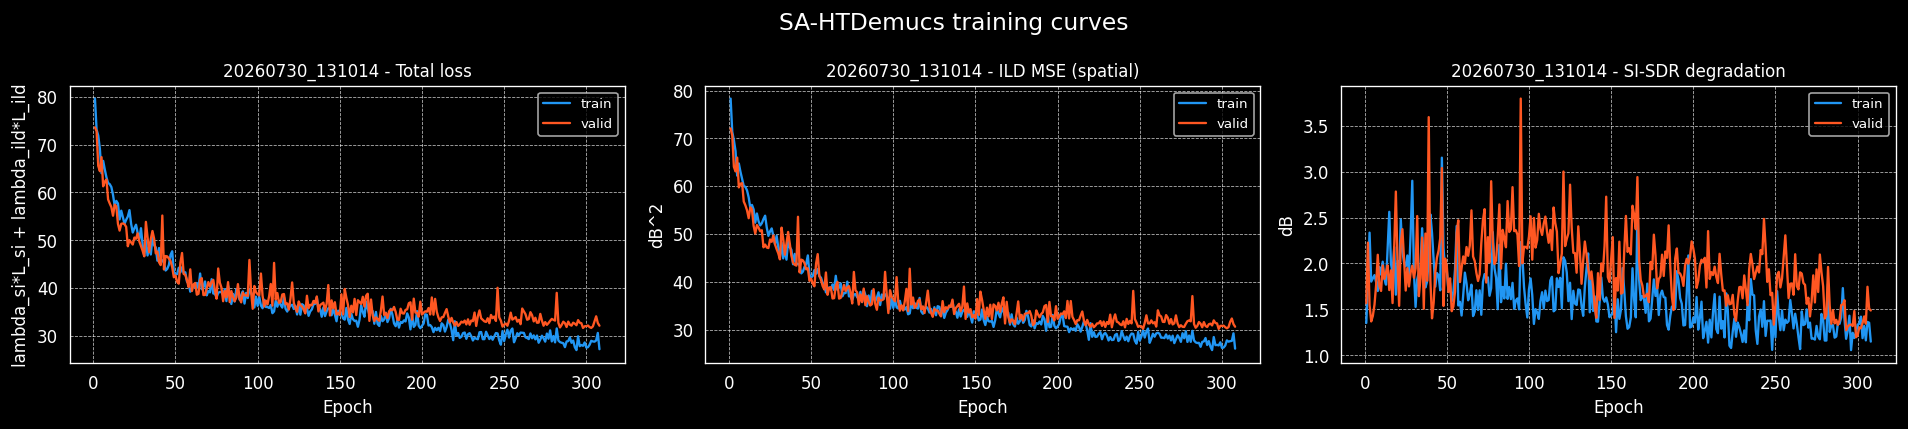

In [4]:
_HIST_PANELS = [
    # (train_key,    valid_key,     title,                ylabel)
    ("train_total", "valid_total", "Total loss",         "lambda_si*L_si + lambda_ild*L_ild"),
    ("train_ild",   "valid_ild",   "ILD MSE (spatial)",  "dB^2"),
    ("train_si",    "valid_si",    "SI-SDR degradation", "dB"),
]

_with_hist = [r for r in runs if r["history"] is not None]
if not _with_hist:
    print("No history_*.json found in the run directories - nothing to plot.")
else:
    fig, axes = plt.subplots(len(_with_hist), len(_HIST_PANELS),
                             figsize=(16, 3.6 * len(_with_hist)), dpi=120, squeeze=False)
    for row, r in enumerate(_with_hist):
        history = json.loads(r["history"].read_text(encoding="utf-8"))
        epochs  = np.arange(1, len(history["train_total"]) + 1)
        for col, (tk, vk, title, ylabel) in enumerate(_HIST_PANELS):
            ax = axes[row, col]
            ax.plot(epochs, history[tk], color="#2196F3", lw=1.4, label="train")
            ax.plot(epochs, history[vk], color="#FF5722", lw=1.4, label="valid")
            ax.set_title(f"{r['label']} - {title}", fontsize=10)
            ax.set_xlabel("Epoch")
            ax.set_ylabel(ylabel)
            ax.legend(fontsize=8)
            ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
            ax.set_axisbelow(True)
        print(f"{r['label']:<28} {len(epochs)} epochs, "
              f"best valid ILD = {min(history['valid_ild']):.4f} dB^2 "
              f"@ epoch {int(np.argmin(history['valid_ild'])) + 1}")
    plt.suptitle("SA-HTDemucs training curves", fontsize=14)
    plt.tight_layout()
    plt.show()

## Evaluation helpers

Each test track is separated **whole** (demucs `apply_model` handles the internal
overlapped chunking; the spatial heads are then applied once on the full-length
signal, which gives more stable ILD estimates than per-chunk correction), then
scored per source against the ground-truth stem:

- **SI-SDR** (dB) - separation quality.
- **Per-sub-band ILD MAE** (dB) - residual interaural **level**-difference error,
  averaged over time.
- **Per-sub-band ITD MAE** (samples) - residual interaural **time**-difference
  error (optional, `COMPUTE_ITD`).

$$ \text{SI-SDR}(\hat{s}^{(s)}, s_{gt}^{(s)}) = 10 \cdot \log_{10} \left( \frac{\left\| \dfrac{\langle \hat{s}^{(s)}, s_{gt}^{(s)} \rangle}{\|s_{gt}^{(s)}\|^2} \cdot s_{gt}^{(s)} \right\|^2} {\left\| \hat{s}^{(s)} - \dfrac{\langle \hat{s}^{(s)}, s_{gt}^{(s)} \rangle}{\|s_{gt}^{(s)}\|^2} \cdot s_{gt}^{(s)} \right\|^2} \right) \quad \text{[dB]}$$
$$\mathrm{MAE}^{\text{ILD}}_k = \frac{1}{T_f}\sum_t\big|\widehat{\mathrm{ILD}}_k(t) - \mathrm{ILD}_{k,gt}(t)\big|$$

In [5]:
def evaluate_on_tracks(separate_fn, tracks, tag, out_dir: Optional[Path] = None) -> dict:
    """Separate every test track with `separate_fn` and collect per-source metrics.

    `separate_fn` maps a (2, T) mixture on DEVICE to (S, 2, T) estimates.
    """
    print(f"Running {tag} on {len(tracks)} test tracks...")
    res = {}
    for idx, track_dir in enumerate(tracks, 1):
        mix_path = track_dir / "mixture.wav"
        if not mix_path.exists():
            print(f"[{idx}/{len(tracks)}] SKIP - no mixture.wav")
            continue
        print(f"[{idx}/{len(tracks)}] {track_dir.name} ...", end=" ", flush=True)
        t0 = time.perf_counter()

        wav   = load_audio(mix_path, SAMPLE_RATE).to(DEVICE)
        stems = separate_fn(wav).cpu()   # (S, 2, T)

        if out_dir is not None:
            track_out_dir = out_dir / track_dir.name
            track_out_dir.mkdir(parents=True, exist_ok=True)
            for i, src in enumerate(SOURCES):
                torchaudio.save(str(track_out_dir / f"{src}.wav"), stems[i], SAMPLE_RATE)

        track_res = {}
        for i, src in enumerate(SOURCES):
            tgt_path = track_dir / f"{src}.wav"
            if not tgt_path.exists():
                continue
            tgt = load_audio(tgt_path, SAMPLE_RATE)
            est = stems[i]
            T   = min(tgt.shape[-1], est.shape[-1])
            tgt, est = tgt[:, :T], est[:, :T]

            m = dict(
                si_sdr=si_sdr(est, tgt),
                ild_bands_mae=ild_bands_mae(
                    est, tgt, n_fft=EVAL["n_fft"], hop_length=EVAL["hop_length"],
                    n_bands=EVAL["n_bands"], scale=EVAL["scale"], sample_rate=SAMPLE_RATE,
                ),
            )
            if COMPUTE_ITD:
                m["itd_bands_mae"] = itd_bands_mae(
                    est, tgt, n_fft=EVAL["n_fft"], hop_length=EVAL["hop_length"],
                    n_bands=EVAL["n_bands"], scale=EVAL["scale"], sample_rate=SAMPLE_RATE,
                    max_lag=EVAL["max_lag"], beta=EVAL["beta"],
                )
            track_res[src] = m
        res[track_dir.name] = track_res
        print(f"done ({time.perf_counter() - t0:.1f}s)")

    print(f"{tag}: evaluation complete - {len(res)} tracks.\n")
    return res

# Collect the test tracks
test_dir = DATASET_ROOT / "test"
tracks = sorted((p for p in test_dir.iterdir() if p.is_dir()), key=lambda p: p.name.lower())
if LIMIT_TRACKS:
    tracks = tracks[:LIMIT_TRACKS]
print(f"Found {len(tracks)} test tracks.")

Found 50 test tracks.


## Separate the test set with every model

The frozen HT-Demucs backbone is loaded **once** and shared: the baseline (if
`INCLUDE_BASELINE`) runs it directly, and every run wraps that same frozen
instance with its own `SpatialCueModule` heads, rebuilt from the run's
`spatial_config`.  Only the ~0.7 M head parameters are re-allocated per run, so
peak memory stays that of a single HT-Demucs.

The baseline metrics are also **cached** under `RUNS_ROOT/baseline_metrics.json`:
the frozen backbone gives the same numbers in every session, so from the second
run on only the trained head sets are actually separated.  The cache carries the
band layout, the dataset and the track list it was built with, and recomputes
itself whenever any of those changes (or when `USE_BASELINE_CACHE = False`).

In [6]:
# HT-Demucs pre-trained backbone - `get_model` returns a BagOfModels (ensemble
# wrapper); the first underlying HTDemucs is the one SA-HTDemucs wraps.
bag  = get_model("htdemucs")
base = bag.models[0] if hasattr(bag, "models") else bag
base = base.to(DEVICE).eval()

SAMPLE_RATE = base.samplerate
print(f"Backbone   : {type(base).__name__}  sources={list(base.sources)}  "
      f"{SAMPLE_RATE} Hz  segment={float(base.segment):.2f} s")

results_by_model = {}   # label -> {track: {src: {si_sdr, ild_bands_mae, ...}}}

# -- Baseline: frozen pre-trained HTDemucs, no spatial correction --------------
# The backbone never changes, so its metrics are identical in every session and
# are cached on disk.  Only three things can invalidate them - the sub-band band
# layout, the track list and the ITD flag - so they travel with the cache as a
# fingerprint and are compared on load.
BASELINE_CACHE_PATH = RUNS_ROOT / "baseline_metrics.json"
_BAND_KEYS = ("ild_bands_mae", "itd_bands_mae")

def _baseline_fingerprint() -> dict:
    return {"eval": EVAL, "dataset_root": str(DATASET_ROOT),
            "tracks": [t.name for t in tracks],
            "compute_itd": bool(COMPUTE_ITD), "shifts": int(SHIFTS)}

def load_baseline_cache() -> Optional[dict]:
    """Cached baseline metrics, or None when absent, disabled or stale."""
    if not (USE_BASELINE_CACHE and BASELINE_CACHE_PATH.exists()):
        return None
    blob = json.loads(BASELINE_CACHE_PATH.read_text(encoding="utf-8"))
    if blob.get("fingerprint") != _baseline_fingerprint():
        print("Baseline cache is stale (band config, dataset or track list changed) "
              "- recomputing it.")
        return None
    # Per-band curves are stored as plain lists; bring them back as arrays.
    return {
        track: {src: {**m, **{k: np.asarray(m[k]) for k in _BAND_KEYS if k in m}}
                for src, m in track_res.items()}
        for track, track_res in blob["results"].items()
    }

def save_baseline_cache(res: dict) -> None:
    BASELINE_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    BASELINE_CACHE_PATH.write_text(json.dumps({
        "fingerprint": _baseline_fingerprint(),
        "results": {
            track: {src: {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                          for k, v in m.items()}
                    for src, m in track_res.items()}
            for track, track_res in res.items()
        },
    }), encoding="utf-8")
    print(f"Baseline metrics cached to {BASELINE_CACHE_PATH}\n")

if INCLUDE_BASELINE:
    _cached = load_baseline_cache()
    if _cached is not None:
        results_by_model[BASELINE_LABEL] = _cached
        print(f"{BASELINE_LABEL}: reusing cached metrics for {len(_cached)} tracks "
              f"({BASELINE_CACHE_PATH.name}) - set USE_BASELINE_CACHE = False to redo it.\n")
    else:
        def separate_baseline(wav: torch.Tensor) -> torch.Tensor:
            return apply_model(base, wav.unsqueeze(0), shifts=SHIFTS,
                           progress=False).squeeze(0)

        results_by_model[BASELINE_LABEL] = evaluate_on_tracks(
            separate_baseline, tracks, tag=BASELINE_LABEL)
        save_baseline_cache(results_by_model[BASELINE_LABEL])

# -- Each trained head set -----------------------------------------------------
for r in runs:
    model = SAHTDemucs(base, sources=base.sources, **r["spatial"]).to(DEVICE)
    model.spatial_modules.load_state_dict(
        torch.load(r["ckpt"], map_location=DEVICE, weights_only=True)
    )
    model.eval()

    out_dir = (r["run_dir"] / "estimates") if SAVE_ESTIMATES else None
    results_by_model[r["label"]] = evaluate_on_tracks(
        lambda wav, m=model: m.separate(wav, progress=False, shifts=SHIFTS),
        tracks, tag=r["label"], out_dir=out_dir)

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print(f"Evaluated {len(results_by_model)} model(s): {list(results_by_model)}")

Backbone   : HTDemucs  sources=['drums', 'bass', 'other', 'vocals']  44100 Hz  segment=7.80 s
Running htdemucs (baseline) on 50 test tracks...
[1/50] Al James - Schoolboy Facination ... done (13.0s)
[2/50] AM Contra - Heart Peripheral ... done (10.7s)
[3/50] Angels In Amplifiers - I'm Alright ... done (8.6s)
[4/50] Arise - Run Run Run ... done (10.6s)
[5/50] Ben Carrigan - We'll Talk About It All Tonight ... done (12.2s)
[6/50] BKS - Bulldozer ... done (15.8s)
[7/50] BKS - Too Much ... done (10.5s)
[8/50] Bobby Nobody - Stitch Up ... done (10.8s)
[9/50] Buitraker - Revo X ... done (13.3s)
[10/50] Carlos Gonzalez - A Place For Us ... done (11.8s)
[11/50] Cristina Vane - So Easy ... done (12.2s)
[12/50] Detsky Sad - Walkie Talkie ... done (9.1s)
[13/50] Enda Reilly - Cur An Long Ag Seol ... done (8.9s)
[14/50] Forkupines - Semantics ... done (13.1s)
[15/50] Georgia Wonder - Siren ... done (20.1s)
[16/50] Girls Under Glass - We Feel Alright ... done (14.8s)
[17/50] Hollow Ground - Ill Fat

## Summary - SI-SDR and ILD MAE per run

For every model, the per-source metrics are averaged over all test tracks: SI-SDR
in dB (higher is better) and the scalar ILD MAE in dB (mean over the sub-bands,
lower is better).  The table ranks the runs by mean ILD MAE, with `dSI-SDR`
measured against the baseline so the separation / spatial-fidelity trade-off can
be read at a glance - a good head set lowers the ILD MAE at a `dSI-SDR` close to
zero (the SI-SDR degradation penalty of the training loss targets exactly that).

In [7]:
def aggregate(res):
    ag = {src: {"si_sdr": [], "ild_bands_mae": [], "itd_bands_mae": []} for src in SOURCES}
    for track_res in res.values():
        for src, m in track_res.items():
            ag[src]["si_sdr"].append(m["si_sdr"])
            ag[src]["ild_bands_mae"].append(m["ild_bands_mae"])
            if "itd_bands_mae" in m:
                ag[src]["itd_bands_mae"].append(m["itd_bands_mae"])
    return ag

def per_source_scalar(ag):
    """(si_sdr[src], ild_mae[src]) means over tracks, per source."""
    si  = {s: float(np.mean(ag[s]["si_sdr"]))                     for s in SOURCES}
    ild = {s: float(np.mean(np.mean(ag[s]["ild_bands_mae"], 0)))  for s in SOURCES}
    return si, ild

agg_by_model = {label: aggregate(res) for label, res in results_by_model.items()}

rows = []
for label, ag in agg_by_model.items():
    si, ild = per_source_scalar(ag)
    rows.append({
        "model":        label,
        "SI-SDR (dB)":  float(np.mean(list(si.values()))),
        "ILD MAE (dB)": float(np.mean(list(ild.values()))),
    })
summary = pd.DataFrame(rows).set_index("model")

# dSI-SDR relative to the baseline (if present)
if BASELINE_LABEL in summary.index:
    summary["dSI-SDR (dB)"] = summary["SI-SDR (dB)"] - summary.loc[BASELINE_LABEL, "SI-SDR (dB)"]

summary = summary.sort_values("ILD MAE (dB)", ascending=True)

print(f"SA-HTDemucs run comparison - {len(tracks)} test tracks "
      f"(ranked best -> worst ILD MAE)\n")
with pd.option_context("display.float_format", lambda x: f"{x:+.3f}"):
    print(summary)
summary

SA-HTDemucs run comparison - 50 test tracks (ranked best -> worst ILD MAE)

                     SI-SDR (dB)  ILD MAE (dB)  dSI-SDR (dB)
model                                                       
20260730_131014           +7.320        +3.659        -0.082
htdemucs (baseline)       +7.403        +6.324        +0.000


,SI-SDR (dB),ILD MAE (dB),dSI-SDR (dB)
model,,,
20260730_131014,7.320472,3.659284,-0.0823
htdemucs (baseline),7.402773,6.324218,0.0000


## SI-SDR per source

In [8]:
# Per-source SI-SDR, one column per model (baseline first when present).
_labels = ([BASELINE_LABEL] if BASELINE_LABEL in agg_by_model else []) + \
          [l for l in agg_by_model if l != BASELINE_LABEL]

si_table = pd.DataFrame(
    {label: {src: float(np.mean(agg_by_model[label][src]["si_sdr"])) for src in SOURCES}
     for label in _labels}
).reindex(SOURCES)
si_table.loc["All"] = si_table.mean(axis=0)

print("SI-SDR (dB) per source - higher is better")
with pd.option_context("display.float_format", lambda x: f"{x:+.2f}"):
    print(si_table)
si_table

SI-SDR (dB) per source - higher is better
        htdemucs (baseline)  20260730_131014
drums                 +9.78            +9.62
bass                  +7.66            +7.44
other                 +4.29            +4.38
vocals                +7.88            +7.85
All                   +7.40            +7.32


,htdemucs (baseline),20260730_131014
drums,9.778259,9.618534
bass,7.655935,7.437883
other,4.293331,4.376005
vocals,7.883565,7.849468
All,7.402773,7.320472


## Track ranking by scalar ILD MAE

For one model, the per-sub-band `ild_bands_mae` of each track is collapsed into a
single **scalar ILD MAE** (mean over the frequency bands) per source; the `mean`
column averages the four sources.  Tracks go from the lowest ILD MAE (the
**best**) to the highest (the **worst**).  `RANK_LABEL` selects which model is
ranked - by default the best run of the summary table above.

In [9]:
RANK_LABEL = next((l for l in summary.index if l != BASELINE_LABEL), BASELINE_LABEL)

rows = {}
for track_name, track_res in results_by_model[RANK_LABEL].items():
    per_src = {src: float(np.mean(track_res[src]["ild_bands_mae"]))
               for src in SOURCES if src in track_res}
    if not per_src:
        continue
    per_src["mean"] = float(np.mean(list(per_src.values())))
    rows[track_name] = per_src

ild_ranking = pd.DataFrame.from_dict(rows, orient="index", columns=SOURCES + ["mean"])
ild_ranking = ild_ranking.sort_values("mean", ascending=True)
ild_ranking.index.name = "track"

print(f"Scalar ILD MAE (dB) per track for {RANK_LABEL!r} - ranked best -> worst\n")
with pd.option_context("display.max_rows", None, "display.float_format", lambda x: f"{x:6.3f}"):
    print(ild_ranking)
print(f"\nBest:  {ild_ranking.index[0]}  ({ild_ranking['mean'].iloc[0]:.3f} dB)")
print(f"Worst: {ild_ranking.index[-1]}  ({ild_ranking['mean'].iloc[-1]:.3f} dB)")
ild_ranking

Scalar ILD MAE (dB) per track for '20260730_131014' - ranked best -> worst

                                                   drums   bass  other  \
track                                                                    
Enda Reilly - Cur An Long Ag Seol                  3.363  2.262  2.266   
Signe Jakobsen - What Have You Done To Me          1.569  3.737  2.856   
Nerve 9 - Pray For The Rain                        1.661  2.575  1.599   
Motor Tapes - Shore                                3.739  3.064  2.376   
Little Chicago's Finest - My Own                   2.892  2.880  3.316   
Georgia Wonder - Siren                             2.132  4.291  1.907   
Ben Carrigan - We'll Talk About It All Tonight     3.158  3.388  1.376   
Angels In Amplifiers - I'm Alright                 2.046  4.288  2.952   
BKS - Too Much                                     2.733  3.370  2.308   
Secretariat - Over The Top                         2.278  3.131  1.382   
Bobby Nobody - Stitch Up            

,drums,bass,other,vocals,mean
track,,,,,
Enda Reilly - Cur An Long Ag Seol,3.362541,2.262266,2.266108,0.792934,2.170962
Signe Jakobsen - What Have You Done To Me,1.569418,3.737386,2.855702,1.008267,2.292693
Nerve 9 - Pray For The Rain,1.660826,2.575144,1.599103,4.876774,2.677962
Motor Tapes - Shore,3.739207,3.063695,2.375507,1.823653,2.750516
Little Chicago's Finest - My Own,2.891804,2.880003,3.315737,1.925938,2.753370
Georgia Wonder - Siren,2.132009,4.291481,1.907134,2.851014,2.795410
Ben Carrigan - We'll Talk About It All Tonight,3.158068,3.387755,1.375620,3.260591,2.795508
Angels In Amplifiers - I'm Alright,2.046499,4.288091,2.952479,2.767597,3.013666
BKS - Too Much,2.732679,3.369989,2.308012,3.652395,3.015769


## Per-band ILD MAE - every run vs the baseline

One panel per source; each curve is a model's mean per-band ILD MAE over the test
set, i.e. for band $k$ and source $s$:

$$  \mathrm{MAE}_{k}^{(s)} = \frac{1}{N} \sum_{n=1}^{N} \mathrm{MAE}_{k,n}^{(s)} \quad\text{[dB]}$$

A head set preserves the level cue better than the frozen backbone where its
curve sits **below** the baseline curve.  With `COMPUTE_ITD = True` the per-band
ITD MAE (in us) is drawn in a second figure.  The curves are also exported as a
ZIP of tab-separated `.txt` files, one per (source, model).

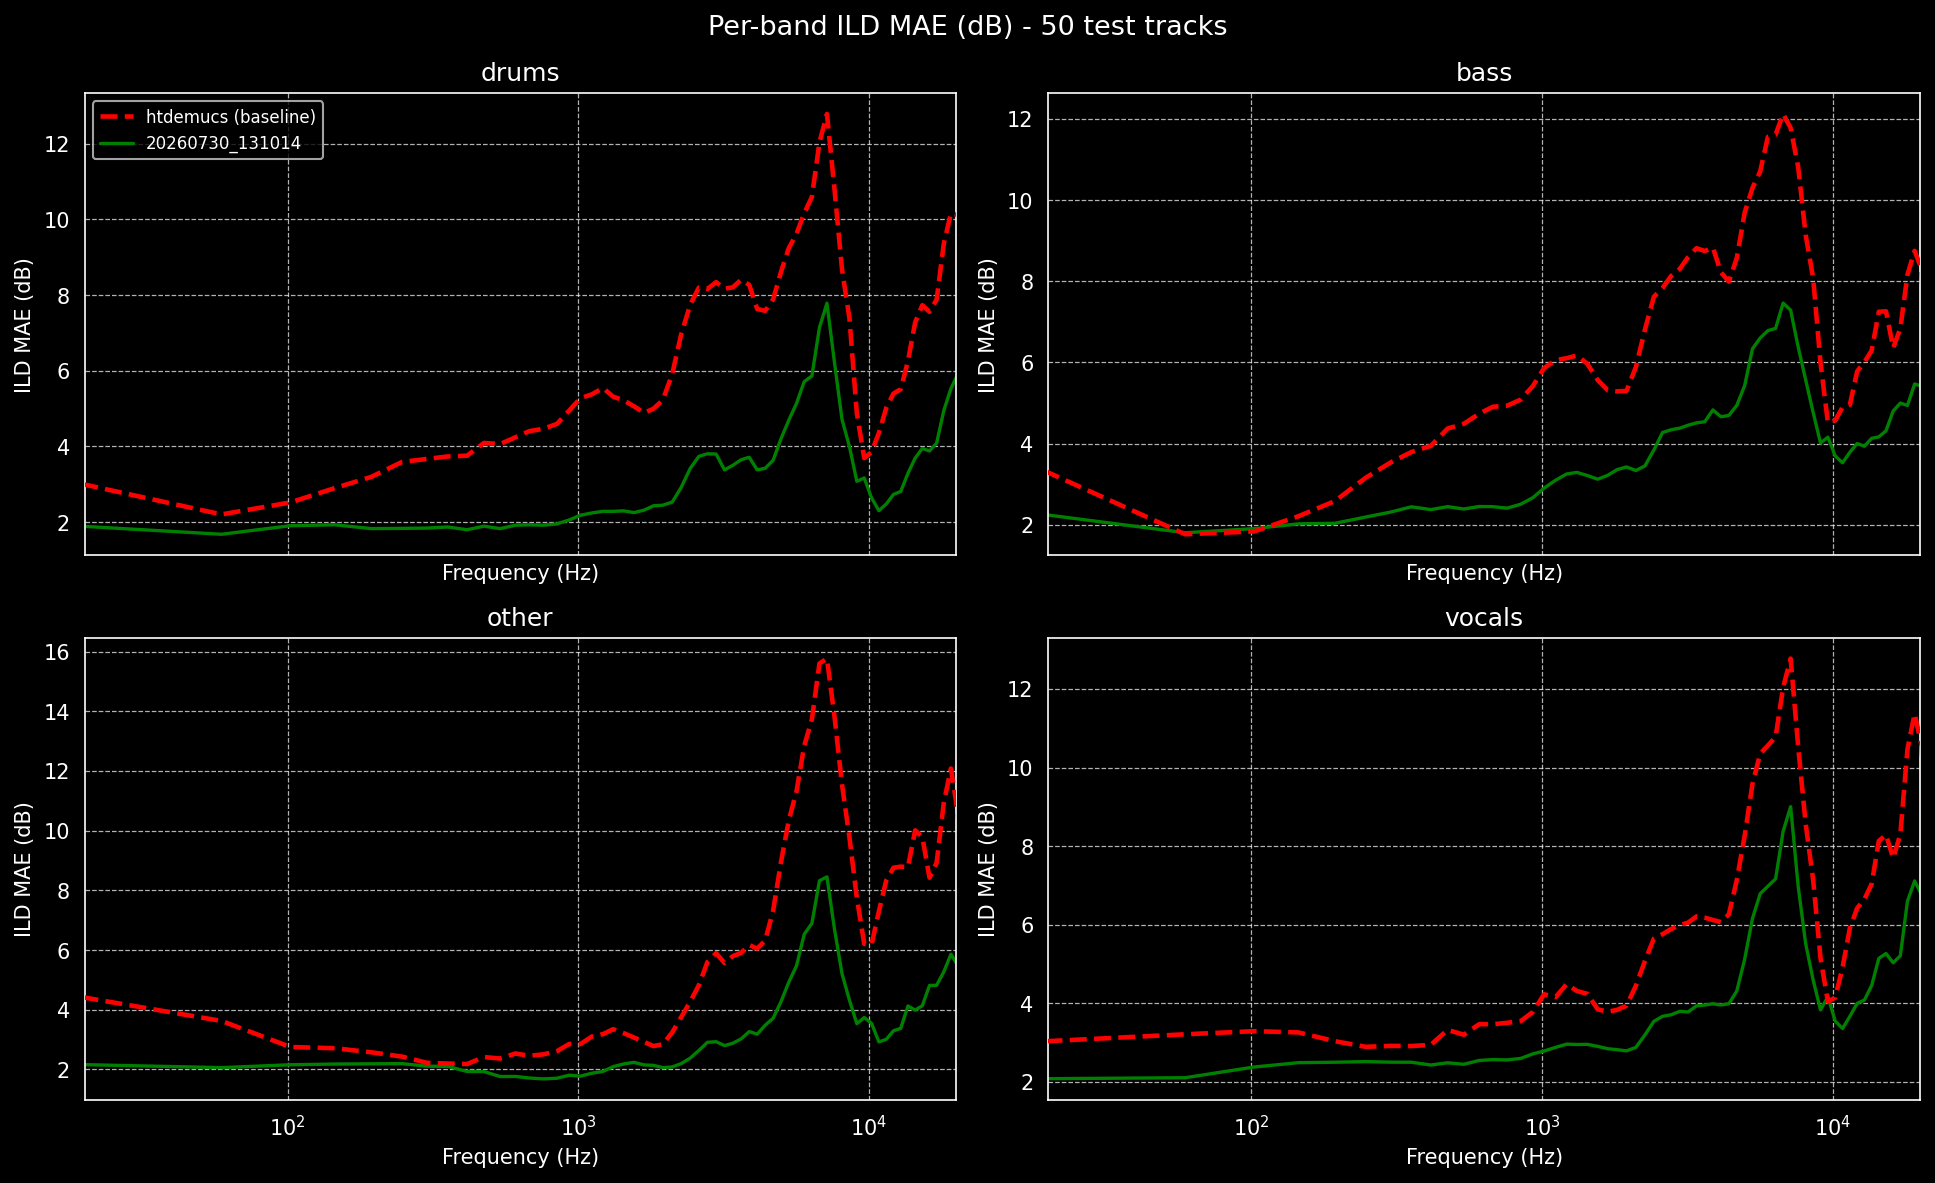

Saved per-band ILD MAE to /nas/home/macerbi/sahtdemucs/runs/sahtdemucs/20260730_131014/ild_mae_per_band.zip


In [12]:
# Band centre frequencies (x-axis): mean Hz per Mel band, or linear midpoints.
n_bands = EVAL["n_bands"]
if EVAL["scale"] == "mel":
    _ba     = mel_bin_assignment(int(EVAL["n_fft"]), n_bands, int(SAMPLE_RATE))
    _bin_hz = np.arange(int(EVAL["n_fft"]) // 2 + 1) * (int(SAMPLE_RATE) / int(EVAL["n_fft"]))
    band_hz = np.array([
        _bin_hz[(_ba == m).numpy()].mean() if (_ba == m).any() else 0.0
        for m in range(n_bands)
    ])
else:
    band_hz = np.linspace(0, SAMPLE_RATE / 2, n_bands, endpoint=False)

def mean_bands(ag, src, key):
    return np.mean(ag[src][key], axis=0)   # (n_bands,)

# One distinct colour/style per model; baseline is a thick black dashed line.
_labels = ([BASELINE_LABEL] if BASELINE_LABEL in agg_by_model else []) + \
          [l for l in agg_by_model if l != BASELINE_LABEL]
#_cmap = plt.cm.tab10(np.linspace(0, 1, max(len(_labels), 1)))

def _style(label, i):
    if label == BASELINE_LABEL:
        return dict(color="red", lw=2.2, ls="--", zorder=3)
    #return dict(color=_cmap[i], lw=1.6, ls="-")
    return dict(color="green", lw=1.6, ls="-")

def plot_metric(key, ylabel, scale=1.0):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=150, sharex=True)
    for ax, src in zip(axes.ravel(), SOURCES):
        for i, label in enumerate(_labels):
            ag = agg_by_model[label]
            if not ag[src][key]:
                continue
            ax.plot(band_hz, mean_bands(ag, src, key) * scale, label=label, **_style(label, i))
        ax.set_xscale("log")
        ax.set_xlim(20, 20000)
        ax.set_title(src)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)
    axes.ravel()[0].legend(fontsize=8, loc="best")
    fig.suptitle(f"Per-band {ylabel} - {len(tracks)} test tracks", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_metric("ild_bands_mae", "ILD MAE (dB)")

if COMPUTE_ITD:
    _US = 1e6 / SAMPLE_RATE   # us per sample (~22.68 us @ 44.1 kHz)
    plot_metric("itd_bands_mae", "ITD MAE (us)", scale=_US)

# -- Export the per-band ILD MAE curves as a ZIP of tab-separated .txt files ----
# With a single run under test the curves belong to it; a multi-run comparison
# is about the set, so it lands one level up next to the run directories.
_run_labels = [l for l in _labels if l != BASELINE_LABEL]
_zip_dir    = runs[0]["run_dir"] if len(_run_labels) == 1 else RUNS_ROOT
_zip_path   = _zip_dir / "ild_mae_per_band.zip"
with zipfile.ZipFile(_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for label in _labels:
        tag = "htdemucs" if label == BASELINE_LABEL else label
        for src in SOURCES:
            buf = io.StringIO()
            buf.write("frequency_hz\tild_mae_dB\n")
            for freq, val in zip(band_hz, mean_bands(agg_by_model[label], src, "ild_bands_mae")):
                buf.write(f"{freq:.4f}\t{float(val):.6f}\n")
            zf.writestr(f"ild_mae_per_band_{src}_{tag}.txt", buf.getvalue())

print(f"Saved per-band ILD MAE to {_zip_path}")